# Demand Forecasting for Inventory Risk Reduction

## Table of Contents
1. **Executive Summary**
2. **Problem Definition**
3. **Data Description**
4. **Data Processing**
5. **Feature Engineering**
6. **Exploratory Data Analysis (EDA)**
7. **Hypothesis Testing**
8. **Modeling**
9. **Error Analysis**
10. **Conclusion & Business Impact**

## 1. Executive Summary

This project evaluates whether feature-based demand forecasting can reduce inventory risk compared to a seasonal baseline modelusing large-scale retail transaction data.

### Key Results

- Dataset size: **10M+ transaction records**
- Baseline model error (RMSE): **26,460**
- Feature-based model error (RMSE): **23,440**

➡ Forecast error reduced by **3,020 units**

This corresponds to an average reduction of approximately **34 units of demand error per day**.

### Business Impact

Improved forecasting accuracy directly supports:

- Reduced **overstock risk**
- Lower **stockout probability**
- More stable **inventory planning**

## 2. Problem Definition

Retail demand forecasting is critical for inventory management.

Inaccurate forecasts can lead to:

- Overstock (excess inventory holding cost)
- Stockouts (lost sales opportunities)

### Objective

Develop a demand forecasting model that improves prediction accuracy
compared to a seasonal baseline.

### Key Question

Can feature-based machine learning models reduce forecasting error
in daily retail demand data?

## 3. Data Description

**Source Data:** `data.zip` containing `data0.csv` – `data9.csv`  
**Schema:** `date`, `cate`, `name`, `mart`, `tot`  
**Derived Features:** `date_day`, `hour`, `weekday`

**Dataset Size**

- Total rows: **10M+**
- Number of files: **10 CSV files**
- Estimated raw size: **~160 MB**  (compressed dataset)

Given the dataset size, the data cannot be safely processed in memory at once.  
Therefore, the preprocessing pipeline uses **chunk-based processing** to ensure memory-efficient handling.

---

### Data Characteristics & Challenges

The dataset presents several practical challenges commonly encountered in real-world retail data:

- **Large-scale dataset** requiring memory-efficient processing
- **Missing values** (e.g., missing product names)
- **Inconsistent string formatting** (whitespace, inconsistent naming)
- **Zero-sales observations**, which can distort percentage-based error metrics

---

### Data Quality Considerations

Special care is required during preprocessing to address potential biases in model evaluation:

- Missing product identifiers must be handled carefully
- Text normalization is required to reduce category noise
- Zero-sales observations may distort metrics such as **MAPE**, requiring cautious interpretation

## 4. Data Processing

The raw dataset consists of multiple large CSV files compressed in a single archive.

To efficiently process the data while avoiding memory limitations,
the pipeline performs the following steps:

1. Extract the compressed dataset
2. Locate all CSV files
3. Read the data in chunks
4. Clean and normalize string fields
5. Handle missing values
6. Store cleaned chunks as Parquet files

Using chunk-based processing ensures that even very large datasets
can be processed without loading the entire dataset into memory.

In [2]:

import os, glob, zipfile
from dataclasses import dataclass
from typing import Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import f_oneway, pearsonr

pd.set_option("display.max_columns", 50)

@dataclass
class Config:
    zip_path: str = "./data.zip"
    extract_dir: str = "./data_extracted"
    out_dir: str = "./output"
    file_pattern: str = "data*.csv"
    usecols: Tuple[str, ...] = ("date", "cate", "name", "mart", "tot")
    chunksize: int = 500_000
    parse_date_col: str = "date"

cfg = Config()

def ensure_dir(path: str) -> None:
    os.makedirs(path, exist_ok=True)

ensure_dir(cfg.out_dir)
cfg


Config(zip_path='./data.zip', extract_dir='./data_extracted', out_dir='./output', file_pattern='data*.csv', usecols=('date', 'cate', 'name', 'mart', 'tot'), chunksize=500000, parse_date_col='date')

In [3]:

def unzip_data(cfg: Config) -> None:
    ensure_dir(cfg.extract_dir)
    if not os.path.exists(cfg.zip_path):
        raise FileNotFoundError(f"Zip not found: {cfg.zip_path}")
    with zipfile.ZipFile(cfg.zip_path, "r") as zf:
        zf.extractall(cfg.extract_dir)
    print(f"[OK] Unzipped to: {cfg.extract_dir}")

def find_csv_files(cfg: Config):
    pattern = os.path.join(cfg.extract_dir, "**", cfg.file_pattern)
    files = sorted(glob.glob(pattern, recursive=True))
    if not files:
        raise FileNotFoundError(f"No CSV files matched pattern: {pattern}")
    print(f"[OK] Found {len(files)} CSV files")
    for f in files[:10]:
        print(" -", f)
    if len(files) > 10:
        print(f" ... and {len(files)-10} more")
    return files


In [4]:
def normalize_simple(s: pd.Series) -> pd.Series:
    s = s.fillna("").astype("string")
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

## 5. Feature Engineering

After cleaning the dataset, several time-based features are created
to capture temporal patterns in sales.

These features help the model identify patterns such as
daily demand cycles and weekday effects.

Engineered features:

- **date_day**: daily-level timestamp for aggregation
- **hour**: hour of the transaction
- **weekday**: day of week (0=Monday)

In [5]:
def iter_clean_chunks(file_path: str, cfg: Config):
    dtype = {"cate": "string", "name": "string", "mart": "string", "tot": "float32"}

    reader = pd.read_csv(
        file_path,
        usecols=list(cfg.usecols),
        chunksize=cfg.chunksize,
        dtype=dtype,
        low_memory=True,
    )

# --------------------------------------------------
# Feature Engineering
# Create time-based features for EDA and forecasting
# --------------------------------------------------

    for chunk in reader:
        chunk[cfg.parse_date_col] = pd.to_datetime(chunk[cfg.parse_date_col], errors="coerce")
        chunk = chunk.dropna(subset=[cfg.parse_date_col, "cate", "tot"])
        chunk = chunk[chunk["tot"] >= 0]

        chunk["cate"] = normalize_simple(chunk["cate"])
        chunk["mart"] = normalize_simple(chunk["mart"])

        # 핵심: 상품명 결측은 카테고리로 대체 → 데이터 손실 최소화
        chunk["name"] = chunk["name"].fillna(chunk["cate"])
        chunk["name"] = normalize_simple(chunk["name"])

        chunk["date_day"] = chunk[cfg.parse_date_col].dt.floor("D")
        chunk["hour"] = chunk[cfg.parse_date_col].dt.hour.astype("int16")
        chunk["weekday"] = chunk[cfg.parse_date_col].dt.weekday.astype("int16")

        yield chunk

In [6]:

def merge_to_parquet_parts(cfg: Config, files):
    part_dir = os.path.join(cfg.out_dir, "merged_parts")
    ensure_dir(part_dir)

    part_idx = 0
    total_rows = 0

    for file_path in files:
        print(f"\n[INFO] Reading: {file_path}")
        for chunk in iter_clean_chunks(file_path, cfg):
            part_path = os.path.join(part_dir, f"part_{part_idx:05d}.parquet")
            chunk.to_parquet(part_path, index=False)
            total_rows += len(chunk)
            part_idx += 1

            if part_idx % 10 == 0:
                print(f"  ... wrote {part_idx} parts | rows so far: {total_rows:,}")

    print(f"\n[OK] Parts saved at: {part_dir}")
    print(f"[OK] Total cleaned rows: {total_rows:,}")
    return part_dir


In [7]:

part_dir = os.path.join(cfg.out_dir, "merged_parts")
if not os.path.exists(part_dir) or len(glob.glob(os.path.join(part_dir, "*.parquet"))) == 0:
    unzip_data(cfg)
    files = find_csv_files(cfg)
    part_dir = merge_to_parquet_parts(cfg, files)
else:
    print("[OK] parquet parts already exist:", part_dir)

part_dir


[OK] parquet parts already exist: ./output\merged_parts


'./output\\merged_parts'

In [8]:
## Load Dataset (Parquet → df)

def load_parts(part_dir: str) -> pd.DataFrame:
    part_files = sorted(glob.glob(os.path.join(part_dir, "*.parquet")))
    if not part_files:
        raise FileNotFoundError(f"No parquet parts found in {part_dir}")
    df = pd.concat((pd.read_parquet(p) for p in part_files), ignore_index=True)
    print(f"[OK] Loaded merged df rows: {len(df):,}")
    return df

df = load_parts(part_dir)
df.head()


[OK] Loaded merged df rows: 10,000,000


,date,cate,name,mart,tot,date_day,hour,weekday
0,2020-01-01 13:32:17,Eggplant Oriental,,2,7.0,2020-01-01,13,2
1,2020-01-01 13:32:37,Ham,Cooked Italian,8,4.0,2020-01-01,13,2
2,2020-01-01 13:36:51,Cheese,Parmesan Cubes,9,3.0,2020-01-01,13,2
3,2020-01-01 13:36:55,Bay Leaf,,2,4.0,2020-01-01,13,2
4,2020-01-01 13:37:26,Bread Fig And Almond,,8,11.0,2020-01-01,13,2


## 6. Exploratory Data Analysis (EDA)

EDA aims to answer three key questions:

1. Are there systematic demand patterns?
2. How large is the variability in daily sales?
3. Are there structural signals useful for forecasting?



In [11]:
# =========================================
# Basic Dataset Overview
# 목적:
# 데이터 규모, 기간, 카테고리 다양성 등을 확인
# =========================================
print("Rows:", len(df))
print("Date range:", df["date"].min(), "~", df["date"].max())
print("Unique cate:", df["cate"].nunique())
print("Unique name (non-empty):", df.loc[df["name"] != "", "name"].nunique())
print("Unique mart (non-empty):", df.loc[df["mart"] != "", "mart"].nunique())
print("Zero-sales rate:", (df["tot"] == 0).mean())
df[["tot"]].describe()


Rows: 10000000
Date range: 2020-01-01 13:30:01 ~ 2023-12-31 23:49:42
Unique cate: 419
Unique name (non-empty): 577
Unique mart (non-empty): 9
Zero-sales rate: 0.0549451


,tot
count,1.000000e+07
mean,9.683823e+00
std,8.120464e+00
min,0.000000e+00
25%,2.000000e+00
50%,8.000000e+00
75%,1.600000e+01
max,3.600000e+01


In [13]:

def eda_and_save(df: pd.DataFrame, cfg: Config) -> Dict[str, object]:
    ensure_dir(cfg.out_dir)

    summary = {
        "n_rows": int(len(df)),
        "date_min": str(df["date"].min()),
        "date_max": str(df["date"].max()),
        "n_cate": int(df["cate"].nunique()),
        "n_name_nonempty": int(df.loc[df["name"] != "", "name"].nunique()),
        "n_mart_nonempty": int(df.loc[df["mart"] != "", "mart"].nunique()),
        "zero_sales_rate": float((df["tot"] == 0).mean()),
    }

    hourly = df.groupby("hour")["tot"].sum().sort_index()
    plt.figure(figsize=(10, 4))
    hourly.plot(kind="bar")
    plt.title("Total Sales by Hour")
    plt.xlabel("Hour"); plt.ylabel("Total tot")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.out_dir, "eda_sales_by_hour.png"), dpi=150)
    plt.close()

    weekday = df.groupby("weekday")["tot"].sum().sort_index()
    plt.figure(figsize=(8, 4))
    weekday.plot(kind="bar")
    plt.title("Total Sales by Weekday (0=Mon)")
    plt.xlabel("Weekday"); plt.ylabel("Total tot")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.out_dir, "eda_sales_by_weekday.png"), dpi=150)
    plt.close()

    cate_top = df.groupby("cate")["tot"].sum().sort_values(ascending=False).head(20)
    plt.figure(figsize=(10, 6))
    cate_top.sort_values().plot(kind="barh")
    plt.title("Top 20 Categories by Total Sales")
    plt.xlabel("Total tot")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.out_dir, "eda_top20_categories.png"), dpi=150)
    plt.close()

    daily_total = df.groupby("date_day")["tot"].sum().sort_index()
    plt.figure(figsize=(12, 4))
    daily_total.plot()
    plt.title("Daily Total Sales Trend")
    plt.xlabel("Date"); plt.ylabel("Total tot")
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.out_dir, "eda_daily_total_trend.png"), dpi=150)
    plt.close()

    hourly.to_csv(os.path.join(cfg.out_dir, "table_hourly_sales.csv"))
    weekday.to_csv(os.path.join(cfg.out_dir, "table_weekday_sales.csv"))
    cate_top.to_csv(os.path.join(cfg.out_dir, "table_top20_categories.csv"))
    daily_total.to_csv(os.path.join(cfg.out_dir, "table_daily_total.csv"))

    pd.Series(summary, dtype="object").to_json(os.path.join(cfg.out_dir, "eda_summary.json"), force_ascii=False)
    print(f"[OK] EDA outputs saved to {cfg.out_dir}")
    return summary

summary = eda_and_save(df, cfg)
summary


[OK] EDA outputs saved to ./output


{'n_rows': 10000000,
 'date_min': '2020-01-01 13:30:01',
 'date_max': '2023-12-31 23:49:42',
 'n_cate': 419,
 'n_name_nonempty': 577,
 'n_mart_nonempty': 9,
 'zero_sales_rate': 0.0549451}

In [14]:
daily = df.groupby(["date_day", "weekday"])["tot"].sum().reset_index()
weekday_mean = daily.groupby("weekday")["tot"].mean()
weekday_mean

weekday
0    74489.437500
1    65057.683594
2    63975.343750
3    65342.113281
4    64963.812500
5    65322.085938
6    64858.007812
Name: tot, dtype: float32

### Category Demand Volatility

Demand characteristics differ across product categories.

To understand how demand scale relates to variability,
the average daily sales and volatility (standard deviation)
are compared across categories.

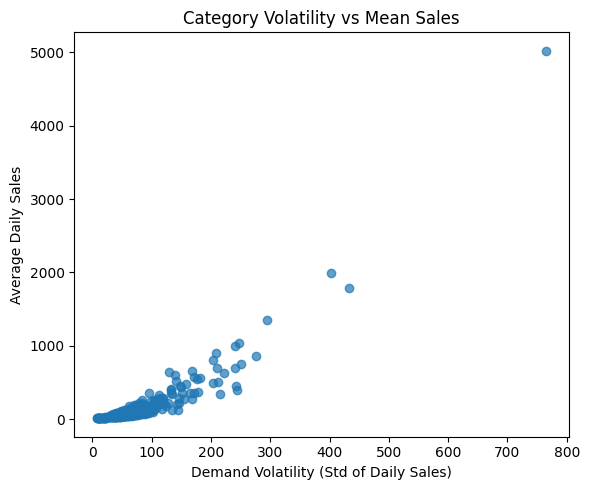

In [15]:
# =========================================
# Category Volatility vs Mean Sales
# 목적:
# 카테고리별 수요 규모와 변동성 관계 확인
# =========================================

cate_daily = (
    df.groupby(["cate", "date_day"])["tot"]
      .sum()
      .reset_index()
)

cate_stats = (
    cate_daily.groupby("cate")["tot"]
    .agg(mean_sales="mean", std_sales="std")
    .reset_index()
)

plt.figure(figsize=(6,5))

plt.scatter(
    cate_stats["std_sales"],
    cate_stats["mean_sales"],
    alpha=0.7
)

plt.xlabel("Demand Volatility (Std of Daily Sales)")
plt.ylabel("Average Daily Sales")
plt.title("Category Volatility vs Mean Sales")

plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "category_volatility_vs_mean.png"), dpi=150)
plt.show()

**Insight**

Categories with higher average demand tend to exhibit
larger demand volatility.

This suggests that high-volume categories may also
be more difficult to forecast due to stronger demand fluctuations.

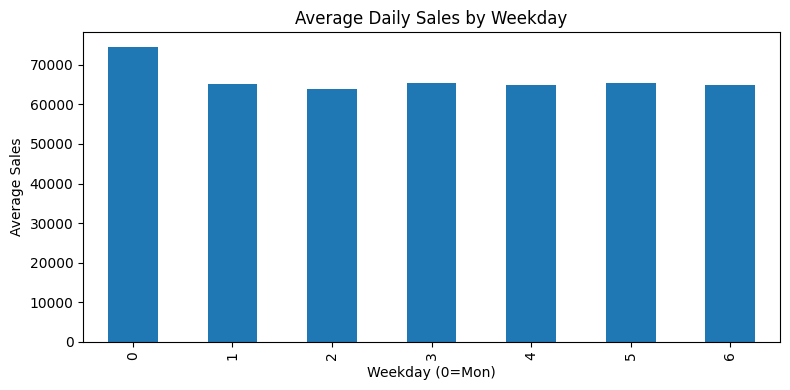

In [17]:
# =========================================
# Visualization: Average Daily Sales by Weekday
# =========================================
plt.figure(figsize=(8,4))

weekday_mean.plot(kind="bar")

plt.title("Average Daily Sales by Weekday")
plt.xlabel("Weekday (0=Mon)")
plt.ylabel("Average Sales")

plt.tight_layout()
plt.show()

### Insight

The visualization suggests that sales levels vary across weekdays,
indicating the presence of weekly demand patterns.

Such patterns justify the inclusion of **weekday-based features**
in the forecasting model.

This observation is later validated through statistical hypothesis testing.


## 7. Hypothesis Testing

Exploratory analysis suggested that sales patterns vary across
time dimensions and category characteristics. 

Statistical testing helps validate whether
observed patterns are statistically meaningful
rather than random fluctuations.

To validate whether these observed patterns are statistically meaningful,
three hypotheses are tested:

### H1. Weekday Effect
Daily total sales differ across weekdays.

### H2. Hourly Effect
Hourly sales patterns differ across time of day.

### H3. Demand Volatility by Category
Category-level demand volatility is positively associated with
average sales volume.

These tests provide statistical evidence that demand is not random,
and that forecasting models should account for weekday, hour,
and category-level demand structure.


### Statistical Tests

- **ANOVA** is used to test whether mean sales differ across groups
  (weekday and hour).
- **Pearson correlation** is used to test whether category-level
  demand volatility is associated with average sales.

In [18]:
def hypothesis_tests(df: pd.DataFrame, cfg: Config) -> Dict[str, object]:
    """
    목적: EDA에서 확인한 패턴이 통계적으로 유의한지 검증한다.

    H1: 요일별 일매출 차이가 존재하는가?         -> ANOVA
    H2: 시간대별 판매량 차이가 존재하는가?       -> ANOVA
    H3: 카테고리 평균 판매량과 변동성이 관련 있는가? -> Pearson correlation
    """
    ensure_dir(cfg.out_dir)
    results = {}

    # =========================================
    # H1. Weekday Effect
    # 일별 총 판매량을 요일별로 나누어 평균 차이가 있는지 검정
    # =========================================
    daily = df.groupby("date_day")["tot"].sum().reset_index()
    daily["weekday"] = pd.to_datetime(daily["date_day"]).dt.weekday

    # weekday별 sales array 생성
    weekday_groups = [g["tot"].values for _, g in daily.groupby("weekday")]

    # 그룹이 2개 이상일 때만 ANOVA 수행
    if len(weekday_groups) >= 2:
        f_stat, p_val = f_oneway(*weekday_groups)

        results["H1_anova_weekday_daily_total"] = {
            "f_stat": float(f_stat),
            "p_value": float(p_val)
        }

    # =========================================
    # H2. Hourly Effect
    # 일자-시간 단위 판매량을 기준으로 시간대별 평균 차이를 검정
    # =========================================
    hourly = df.groupby(["date_day", "hour"])["tot"].sum().reset_index()

    # hour별 sales array 생성
    hour_groups = [g["tot"].values for _, g in hourly.groupby("hour")]

    if len(hour_groups) >= 2:
        f_stat, p_val = f_oneway(*hour_groups)

        results["H2_anova_hourly_sales"] = {
            "f_stat": float(f_stat),
            "p_value": float(p_val)
        }

    # =========================================
    # H3. Category-level Volatility vs Mean
    # 카테고리별 일판매량의 평균(mean)과 표준편차(std) 계산
    # 평균 판매량이 큰 카테고리일수록 변동성이 큰지 검정
    # =========================================
    cate_daily = df.groupby(["date_day", "cate"])["tot"].sum().reset_index()

    cate_stats = (
        cate_daily
        .groupby("cate")["tot"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # 관측치가 너무 적은 카테고리는 제외
    # (희소 카테고리는 std 추정이 불안정할 수 있음)
    cate_stats = cate_stats[cate_stats["count"] >= 10]

    if len(cate_stats) >= 3:
        r, p = pearsonr(cate_stats["std"].values, cate_stats["mean"].values)

        results["H3_corr_cate_volatility_vs_mean"] = {
            "pearson_r": float(r),
            "p_value": float(p),
            "n": int(len(cate_stats))
        }

    # =========================================
    # 결과 저장
    # =========================================
    pd.Series(results, dtype="object").to_json(
        os.path.join(cfg.out_dir, "hypothesis_results.json"),
        force_ascii=False
    )

    cate_stats.to_csv(
        os.path.join(cfg.out_dir, "table_cate_stats_mean_std.csv"),
        index=False
    )

    # H3 시각화: 카테고리 평균 판매량 vs 변동성
    if len(cate_stats) >= 3:
        plt.figure(figsize=(6, 5))
        plt.scatter(cate_stats["std"], cate_stats["mean"])
        plt.title("Category Volatility (std) vs Mean Sales")
        plt.xlabel("std (daily sales by category)")
        plt.ylabel("mean (daily sales by category)")
        plt.tight_layout()
        plt.savefig(
            os.path.join(cfg.out_dir, "hypo_scatter_volatility_vs_mean.png"),
            dpi=150
        )
        plt.close()

    print(f"[OK] Hypothesis outputs saved to {cfg.out_dir}")
    return results


# 함수 실행
hypo = hypothesis_tests(df, cfg)
hypo

[OK] Hypothesis outputs saved to ./output


{'H1_anova_weekday_daily_total': {'f_stat': 41.88442611694336, 'p_value': 0.0},
 'H2_anova_hourly_sales': {'f_stat': 7478.626953125, 'p_value': 0.0},
 'H3_corr_cate_volatility_vs_mean': {'pearson_r': 0.9085780382156372,
  'p_value': 0.0,
  'n': 419}}

## 8. Modeling

To evaluate forecasting performance, two models are constructed:

1. **Baseline model** – Seasonal Naive forecasting using the previous week's value  
2. **Feature-based model** – HistGradientBoostingRegressor using engineered features

The baseline provides a simple benchmark, while the feature-based model
leverages historical patterns and calendar information to improve accuracy.
A model that cannot outperform the baseline is not useful in practice.

### 8.1 Baseline Model

A **Seasonal Naive model** is used as the baseline.

This method assumes that sales on a given day are similar to the sales
observed on the same weekday in the previous week.

This simple baseline is commonly used in retail forecasting because
weekly demand patterns are often strong.

In [19]:

def seasonal_naive(y, season=7):
    y = np.asarray(y)
    yhat = np.empty_like(y, dtype=float)
    yhat[:season] = y[:season]
    for i in range(season, len(y)):
        yhat[i] = y[i-season]
    return yhat

### 8.2 Modeling Features

To improve forecasting accuracy, several time-series features are generated:

**Lag Features**
- Lag 1
- Lag 7
- Lag 14
- Lag 28

**Rolling Statistics**
- 7-day rolling mean
- 7-day rolling standard deviation
- 28-day rolling mean

**Calendar Features**
- Day of week
- Month

These features help the model capture short-term trends,
weekly seasonality, and demand volatility.

In [20]:


def make_daily_series_for_category(df: pd.DataFrame, cate_name: str, cfg: Config) -> pd.DataFrame:
    ensure_dir(cfg.out_dir)
    sub = df[df["cate"] == cate_name].copy()
    daily = sub.groupby("date_day")["tot"].sum().sort_index().reset_index()
    full_range = pd.date_range(daily["date_day"].min(), daily["date_day"].max(), freq="D") # 모든 날짜 생성
    daily = daily.set_index("date_day").reindex(full_range, fill_value=0).reset_index()    # 판매 없는 날 수량 0으로 채움
    daily.rename(columns={"index": "date_day", "tot": "tot"}, inplace=True)
    daily.to_csv(os.path.join(cfg.out_dir, f"ts_daily_{cate_name}.csv"), index=False)
    return daily

top_cate = df.groupby("cate")["tot"].sum().sort_values(ascending=False).index[0]
ts_daily = make_daily_series_for_category(df, top_cate, cfg)

def make_features(ts: pd.DataFrame) -> pd.DataFrame:
    d = ts.copy()
    d["date_day"] = pd.to_datetime(d["date_day"])
    d["dow"] = d["date_day"].dt.weekday
    d["month"] = d["date_day"].dt.month
    for lag in [1, 7, 14, 28]:
        d[f"lag_{lag}"] = d["tot"].shift(lag)
    d["roll_mean_7"] = d["tot"].shift(1).rolling(7).mean()
    d["roll_std_7"] = d["tot"].shift(1).rolling(7).std()
    d["roll_mean_28"] = d["tot"].shift(1).rolling(28).mean()
    return d

feat = make_features(ts_daily).dropna().reset_index(drop=True)

### 8.3 Model Training

A **HistGradientBoostingRegressor** is used as the primary forecasting model.

Tree-based gradient boosting models are well suited for this task because:

- they capture nonlinear relationships
- they handle feature interactions effectively
- they perform well on tabular datasets with engineered features

This model is trained using lag and calendar-based predictors
to forecast daily demand.

In [21]:
from sklearn.ensemble import HistGradientBoostingRegressor

test_days = 90
train = feat.iloc[:-test_days].copy()
test  = feat.iloc[-test_days:].copy()

target = "tot"
feature_cols = [c for c in feat.columns if c not in ["date_day", target]]

X_train, y_train = train[feature_cols], train[target].values
X_test,  y_test  = test[feature_cols],  test[target].values

baseline_pred = seasonal_naive(np.r_[y_train, y_test], season=7)[-len(y_test):]

model = HistGradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

### 8.4 Model Evaluation

Model performance is evaluated using several error metrics:

**RMSE**
Measures the magnitude of prediction errors.

**WMAPE**
Weighted Mean Absolute Percentage Error, which is robust
when zero-sales observations are present.

**sMAPE**
Symmetric MAPE, which normalizes percentage error.

These metrics allow a fair comparison between the baseline model
and the feature-based forecasting model.

In [22]:
def wmape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom * 100 if denom != 0 else np.nan

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    denom = np.where(denom == 0, 1.0, denom)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape_zero_adjusted(y_true, y_pred, eps=1.0):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + eps)) * 100

In [23]:
metrics = {
    "RMSE_baseline": rmse(y_test, baseline_pred),
    "RMSE_feature": rmse(y_test, pred),
    "WMAPE_baseline(%)": wmape(y_test, baseline_pred),
    "WMAPE_feature(%)": wmape(y_test, pred),
    "sMAPE_baseline(%)": smape(y_test, baseline_pred),
    "sMAPE_feature(%)": smape(y_test, pred),
    "ZeroAdjMAPE_feature(%)": mape_zero_adjusted(y_test, pred),
    "ZeroAdjMAPE_baseline(%)": mape_zero_adjusted(y_test, baseline_pred)
}
metrics

{'RMSE_baseline': 394.6866267475164,
 'RMSE_feature': 314.177681492477,
 'WMAPE_baseline(%)': np.float64(5.614854111405836),
 'WMAPE_feature(%)': np.float64(4.974039588106959),
 'sMAPE_baseline(%)': np.float64(5.623354353859476),
 'sMAPE_feature(%)': np.float64(4.985405452477651),
 'ZeroAdjMAPE_feature(%)': np.float64(4.979965866033489),
 'ZeroAdjMAPE_baseline(%)': np.float64(5.626895308191741)}

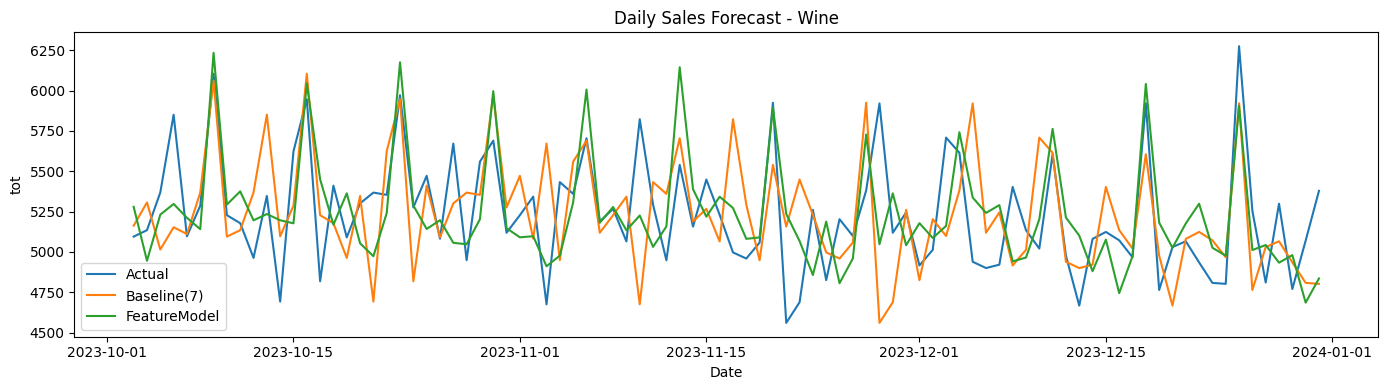

In [24]:

plt.figure(figsize=(14,4))
plt.plot(test["date_day"], y_test, label="Actual")
plt.plot(test["date_day"], baseline_pred, label="Baseline(7)")
plt.plot(test["date_day"], pred, label="FeatureModel")
plt.title(f"Daily Sales Forecast - {top_cate}")
plt.xlabel("Date"); plt.ylabel("tot")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, f"forecast_plot_{top_cate}.png"), dpi=150)
plt.show()


### Predicted vs Actual

To visually assess model performance, predicted demand values
are compared with actual demand values.

If the model performs well, most points should lie close to
the diagonal line, indicating that predictions closely match
the observed demand.

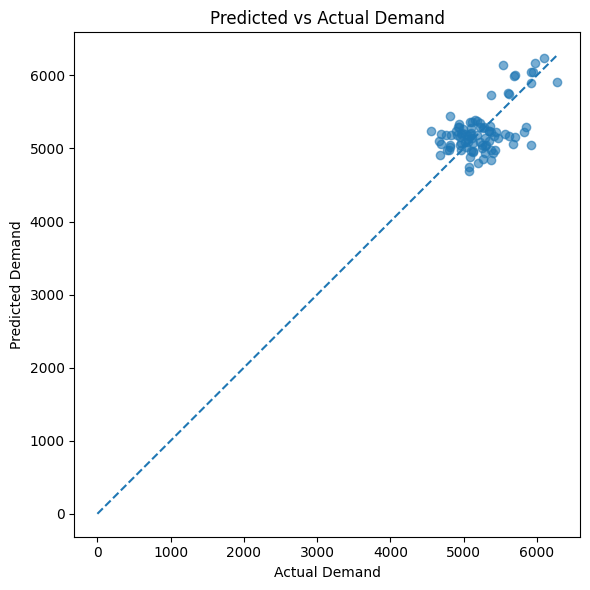

In [25]:
# =========================================
# Predicted vs Actual Demand
# 목적:
# 모델 예측값과 실제값의 일치 정도 시각화
# =========================================

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.6
)

# perfect prediction line
max_val = max(max(y_test), max(pred))

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Predicted vs Actual Demand")

plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "predicted_vs_actual.png"), dpi=150)
plt.show()

### Insight

Most predictions lie close to the diagonal reference line,
indicating that the model captures the overall demand level reasonably well.

However, a mild regression-to-the-mean pattern is observed:
the model tends to slightly overpredict lower demand levels
and underpredict higher demand levels.

This suggests that extreme demand values remain more difficult
for the model to capture accurately.


## 9. Error Analysis

While overall metrics show that the feature-based model improves forecast accuracy,
aggregate metrics alone do not explain **where and why errors occur**.

To better understand the operational implications of forecasting errors,
the prediction results are analyzed across three perspectives:

1. **Top Error Days** – identifying dates with the largest prediction failures  
2. **Weekday Error Patterns** – analyzing systematic weekday effects  
3. **Demand Volume Segmentation** – understanding how errors vary by demand level  

This multi-perspective error analysis helps connect model performance
to **practical inventory risk scenarios**.

### 9.1 Forecast Error by Weekday

Demand patterns in retail often vary across weekdays due to
consumer behavior and operational factors.

To evaluate whether forecast errors follow a systematic weekly pattern,
RMSE is calculated separately for each weekday.

This analysis helps determine:

- whether certain weekdays consistently produce larger errors
- whether the feature-based model improves forecasting stability
  across different days of the week

Understanding weekday error patterns is important for
**operational planning and inventory allocation decisions**.

In [26]:

test_eval = test[["date_day"]].copy()
test_eval["y"] = y_test
test_eval["baseline"] = baseline_pred
test_eval["feature"] = pred
test_eval["weekday"] = pd.to_datetime(test_eval["date_day"]).dt.weekday

by_dow = (test_eval
          .groupby("weekday")
          .apply(lambda g: pd.Series({
              "n": len(g),
              "RMSE_feature": rmse(g["y"].values, g["feature"].values),
              "RMSE_baseline": rmse(g["y"].values, g["baseline"].values),
          }))
          .reset_index())

by_dow.to_csv(os.path.join(cfg.out_dir, "error_by_weekday_rmse.csv"), index=False)
by_dow


,weekday,n,RMSE_feature,RMSE_baseline
0,0,12.0,278.913606,267.485514
1,1,13.0,407.637740,547.139274
2,2,13.0,259.870827,307.711778
3,3,13.0,242.790841,226.220111
4,4,13.0,376.193063,574.522343
5,5,13.0,306.204906,329.918288
6,6,13.0,289.171655,358.147477


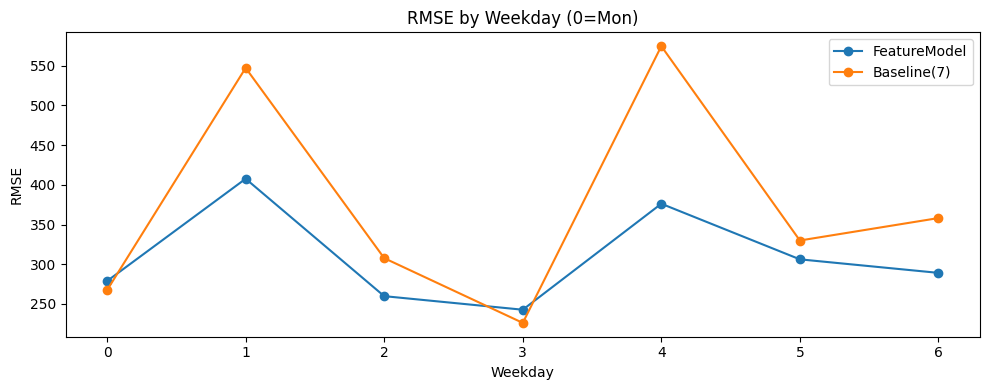

In [27]:

plt.figure(figsize=(10,4))
plt.plot(by_dow["weekday"], by_dow["RMSE_feature"], marker="o", label="FeatureModel")
plt.plot(by_dow["weekday"], by_dow["RMSE_baseline"], marker="o", label="Baseline(7)")
plt.title("RMSE by Weekday (0=Mon)")
plt.xlabel("Weekday"); plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "rmse_by_weekday.png"), dpi=150)
plt.show()


### 9.2 Top Error Days

To identify when the forecasting model fails most severely,
the dates with the largest absolute prediction errors are extracted.

Analyzing the highest-error dates helps answer several key questions:

- Are large errors associated with sudden demand spikes?
- Does the model systematically under-forecast or over-forecast?
- Which dates likely carried the highest operational inventory risk?

By focusing on extreme error cases,
we can better understand the **limitations of the forecasting model
under volatile demand conditions**.

In [28]:
# =========================================
# 테스트 구간에서 절대 오차가 가장 큰 날짜 10개를 추출
# → 모델 실패가 집중된 날짜를 식별
# =========================================

# test_eval: 테스트 구간의 실제값 / baseline / feature 예측값 포함 데이터프레임

test_eval = test_eval.copy()

# 절대 오차 / 방향성 오차 계산
test_eval["abs_error"] = np.abs(test_eval["y"] - test_eval["feature"])
test_eval["signed_error"] = test_eval["y"] - test_eval["feature"]

# 전일 대비 변동폭 계산
test_eval = test_eval.sort_values("date_day").reset_index(drop=True)
test_eval["prev_day"] = test_eval["y"].shift(1)
test_eval["delta_vs_prev_day"] = test_eval["y"] - test_eval["prev_day"]
test_eval["pct_change_vs_prev_day"] = np.where(test_eval["prev_day"].fillna(0).values == 0, np.nan,
    (test_eval["y"] - test_eval["prev_day"]) / test_eval["prev_day"] * 100
)

# 절대 오차 기준 상위 10일 추출
top10_errors = test_eval.sort_values("abs_error", ascending=False).head(10).copy()

# 결과 저장
top10_errors.to_csv(os.path.join(cfg.out_dir, "top10_error_days.csv"), index=False)

top10_errors

,date_day,y,baseline,feature,weekday,abs_error,signed_error,prev_day,delta_vs_prev_day,pct_change_vs_prev_day
56,2023-11-28,5921.0,4560.0,5047.726069,1,873.273931,873.273931,5381.0,540.0,10.035309
49,2023-11-21,4560.0,5157.0,5235.445884,1,675.445884,-675.445884,5925.0,-1365.0,-23.037975
14,2023-10-17,4818.0,5228.0,5450.254611,1,632.254611,-632.254611,5947.0,-1129.0,-18.984362
24,2023-10-27,5672.0,5301.0,5056.532245,4,615.467755,615.467755,5082.0,590.0,11.609603
41,2023-11-13,5540.0,5705.0,6145.422178,0,605.422178,-605.422178,4948.0,592.0,11.964430
38,2023-11-10,5823.0,4675.0,5226.072843,4,596.927157,596.927157,5065.0,758.0,14.965449
3,2023-10-06,5851.0,5153.0,5297.632594,4,553.367406,553.367406,5369.0,482.0,8.977463
61,2023-12-03,5709.0,5099.0,5161.464849,6,547.535151,547.535151,5013.0,696.0,13.883903
89,2023-12-31,5379.0,4802.0,4835.603041,6,543.396959,543.396959,5070.0,309.0,6.094675
11,2023-10-14,4692.0,5097.0,5196.442894,5,504.442894,-504.442894,5347.0,-655.0,-12.249860


**Insight**

The largest errors occur on days with extreme demand spikes.

This suggests that the current model may struggle
to capture sudden changes in demand.

In [29]:
# =========================================
# 9.2 Top Error Case Visualization
# 목적:
# 가장 큰 오차가 발생한 날짜(top1)를 중심으로
# 실제값 / baseline / feature model을 비교
# =========================================

top1_date = top10_errors.iloc[0]["date_day"]

window = 7

case_df = test_eval[
    (test_eval["date_day"] >= top1_date - pd.Timedelta(days=window)) &
    (test_eval["date_day"] <= top1_date + pd.Timedelta(days=window))
].copy()

case_df

,date_day,y,baseline,feature,weekday,abs_error,signed_error,prev_day,delta_vs_prev_day,pct_change_vs_prev_day
49,2023-11-21,4560.0,5157.0,5235.445884,1,675.445884,-675.445884,5925.0,-1365.0,-23.037975
50,2023-11-22,4688.0,5449.0,5067.703038,2,379.703038,-379.703038,4560.0,128.0,2.807018
51,2023-11-23,5261.0,5230.0,4856.844253,3,404.155747,404.155747,4688.0,573.0,12.222696
52,2023-11-24,4825.0,4997.0,5188.386318,4,363.386318,-363.386318,5261.0,-436.0,-8.287397
53,2023-11-25,5203.0,4959.0,4805.820709,5,397.179291,397.179291,4825.0,378.0,7.834197
54,2023-11-26,5099.0,5058.0,4959.264898,6,139.735102,139.735102,5203.0,-104.0,-1.998847
55,2023-11-27,5381.0,5925.0,5728.005126,0,347.005126,-347.005126,5099.0,282.0,5.530496
56,2023-11-28,5921.0,4560.0,5047.726069,1,873.273931,873.273931,5381.0,540.0,10.035309
57,2023-11-29,5119.0,4688.0,5363.240399,2,244.240399,-244.240399,5921.0,-802.0,-13.545010
58,2023-11-30,5245.0,5261.0,5041.359595,3,203.640405,203.640405,5119.0,126.0,2.461418


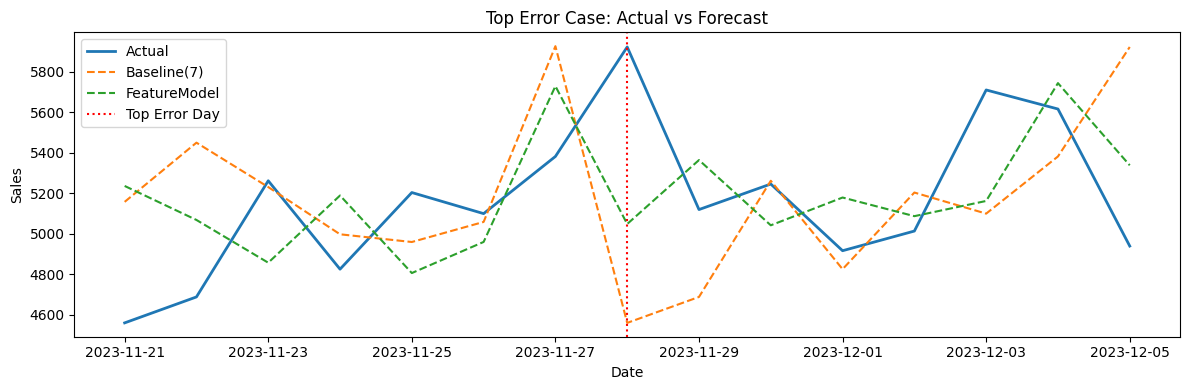

In [30]:
# =========================================
# Top1 Error Day Plot
# =========================================

plt.figure(figsize=(12,4))

plt.plot(case_df["date_day"], case_df["y"], label="Actual", linewidth=2)
plt.plot(case_df["date_day"], case_df["baseline"], label="Baseline(7)", linestyle="--")
plt.plot(case_df["date_day"], case_df["feature"], label="FeatureModel", linestyle="--")

plt.axvline(top1_date, color="red", linestyle=":", label="Top Error Day")

plt.title("Top Error Case: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()

plt.savefig(os.path.join(cfg.out_dir, "top1_error_case_plot.png"), dpi=150)
plt.show()

### 9.3 Error Segmentation by Demand Volume

Forecasting difficulty often varies depending on the level of demand.

To analyze this effect, the test data is segmented into
three demand buckets based on sales volume:

- **Low demand**
- **Mid demand**
- **High demand**

For each segment, multiple error metrics (MAE, RMSE, WMAPE, sMAPE)
are calculated to understand how prediction accuracy varies
across demand conditions.

This segmentation helps identify where forecasting errors are most
likely to translate into **inventory risk**, particularly during
high-demand periods.

### Error vs Demand Level

A scatter plot of actual demand versus absolute forecast error
was examined to determine whether prediction error increases
as demand levels rise.

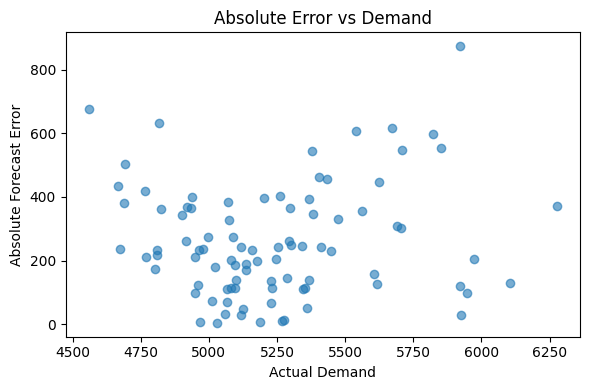

In [31]:
plt.figure(figsize=(6,4))

plt.scatter(
    test_eval["y"],
    np.abs(test_eval["y"] - test_eval["feature"]),
    alpha=0.6
)

plt.title("Absolute Error vs Demand")
plt.xlabel("Actual Demand")
plt.ylabel("Absolute Forecast Error")

plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "error_vs_demand_scatter.png"), dpi=150)
plt.show()

### Volume-based Error Segmentation

Forecast errors were segmented by demand volume to identify where prediction risk is concentrated.

This analysis helps answer:

- Is the model more stable in low, mid, or high demand periods?
- Which demand segment contributes most to operational inventory risk?

In [ ]:

q1, q2 = np.quantile(y_test, [0.33, 0.66])

def volume_bucket(v):
    if v <= q1: return "Low"
    if v <= q2: return "Mid"
    return "High"

test_eval["volume_bucket"] = [volume_bucket(v) for v in test_eval["y"].values]

seg = (test_eval
       .groupby("volume_bucket")
       .apply(lambda g: pd.Series({
           "n": len(g),
           "MAE": float(np.mean(np.abs(g["y"] - g["feature"]))),
           "RMSE": rmse(g["y"].values, g["feature"].values),
           "WMAPE(%)": wmape(g["y"].values, g["feature"].values),
           "sMAPE(%)": smape(g["y"].values, g["feature"].values),
       }))
       .reset_index())

seg = seg.set_index("volume_bucket").loc[["Low", "Mid", "High"]].reset_index()

seg.to_csv(os.path.join(cfg.out_dir, "error_segmentation_by_volume.csv"), index=False)
seg


,volume_bucket,n,MAE,RMSE,WMAPE(%),sMAPE(%)
0,Low,30.0,262.276755,311.270782,5.370745,5.239259
1,Mid,29.0,188.470300,220.740605,3.638544,3.692846
2,High,31.0,326.007104,383.697394,5.790468,5.948909


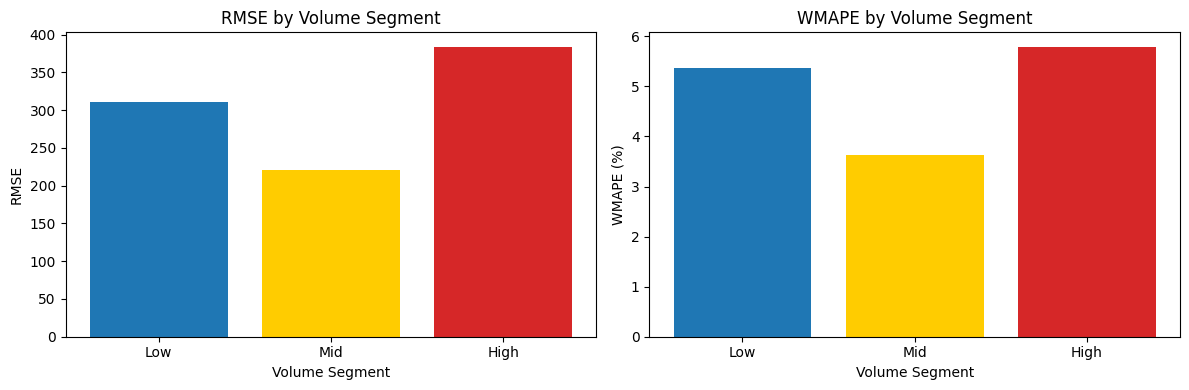

In [36]:
# =========================================
# Volume Segmentation Comparison
# 목적:
# 절대 오차(RMSE)와 상대 오차(WMAPE)를 함께 비교
# =========================================

# segment color mapping
color_map = {
    "Low": "#1f77b4",   # blue
    "Mid": "#ffcc00",   # yellow
    "High": "#d62728"   # red
}

colors = [color_map[v] for v in seg["volume_bucket"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# RMSE
axes[0].bar(
    seg["volume_bucket"],
    seg["RMSE"],
    color=colors
)
axes[0].set_title("RMSE by Volume Segment")
axes[0].set_xlabel("Volume Segment")
axes[0].set_ylabel("RMSE")

# WMAPE
axes[1].bar(
    seg["volume_bucket"],
    seg["WMAPE(%)"],
    color=colors
)
axes[1].set_title("WMAPE by Volume Segment")
axes[1].set_xlabel("Volume Segment")
axes[1].set_ylabel("WMAPE (%)")

plt.tight_layout()
plt.savefig(os.path.join(cfg.out_dir, "segmentation_volume_comparison.png"), dpi=150)
plt.show()

### Insight

The scatter plot shows no strong linear relationship between demand level
and absolute forecast error.

However, segmentation analysis reveals that forecasting performance
still varies across different demand regimes.

The model performs most consistently in the **Mid-demand segment**,
while the **High-demand segment** exhibits the largest RMSE.

This indicates that the model handles typical demand conditions
reasonably well but struggles during periods of unusually high demand.
This behavior is consistent with the earlier error analysis,
where forecast errors were larger in high-demand segments.

These results suggest that forecast difficulty may depend more on
**demand regime** than on demand magnitude alone.

Future improvements may benefit from incorporating external variables
such as **promotions, marketing campaigns, or other demand-driving events**
to better capture sudden demand spikes.

### Business Impact Calculation

To translate model performance into operational impact,
the reduction in forecast error is quantified in total,
daily, and monthly terms.

In [37]:

total_actual = float(np.sum(y_test))
abs_err_base = float(np.sum(np.abs(y_test - baseline_pred)))
abs_err_feat = float(np.sum(np.abs(y_test - pred)))

reduction = abs_err_base - abs_err_feat
daily_reduction = reduction / len(y_test)
monthly_reduction = daily_reduction * 30

impact = {
    "total_actual": total_actual,
    "abs_err_baseline": abs_err_base,
    "abs_err_feature": abs_err_feat,
    "error_reduction_total": reduction,
    "error_reduction_per_day": daily_reduction,
    "error_reduction_per_month": monthly_reduction,
}
pd.Series(impact).to_csv(os.path.join(cfg.out_dir, "business_impact_summary.csv"))
impact


{'total_actual': 471250.0,
 'abs_err_baseline': 26460.0,
 'abs_err_feature': 23440.161558954045,
 'error_reduction_total': 3019.838441045955,
 'error_reduction_per_day': 33.553760456066165,
 'error_reduction_per_month': 1006.6128136819849}

## 10. Conclusion & Business Impact

The feature-based forecasting model improves prediction accuracy compared to the seasonal baseline.

Key findings:

- Forecast error decreased by **3,020 units**
- This corresponds to an average reduction of **34 units per day**
- Estimated reduction of **~1,020 units per month**

Operational implications:

- Reduced overstock risk
- Lower stockout probability
- More stable daily replenishment planning

However, large errors still occur during demand spikes.

Future improvements should incorporate additional external variables such as promotions, marketing events, and stock availability to better capture sudden demand fluctuations.

### Recommended Next Actions

- Prioritize deployment on high-volume categories where forecast improvement has the largest operational value.
- Incorporate external variables such as promotions, campaign schedules, and stock availability.
- Monitor WMAPE as an operational forecasting KPI alongside RMSE.